# 05 — Cross-Algorithm Comparison & Scaling

Loads all per-algorithm CSVs, plots:
1. Cross-algorithm Pareto QPS vs Recall@100
2. Best-config summary table
3. Build time / index size / RSS comparison bars
4. Scaling experiment (100K → 1M base vectors)
5. Anomaly analysis with quantitative evidence
6. Final ranking

In [1]:
import os, sys, time, gc, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import faiss
import psutil
from tqdm import tqdm

sys.path.insert(0, str(Path.cwd()))
import utils

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

DATA = Path('data')
LAB_LIGHT = int(os.environ.get('LAB_LIGHT', '0'))
OUT_RUN = utils.run_mode()
RESULTS = utils.results_dir()
DOCS_IMG = utils.plots_dir()
print(f'OUT_RUN={OUT_RUN}  RESULTS={RESULTS}  DOCS_IMG={DOCS_IMG}')

# Load query + GT
with h5py.File(DATA / 'imagenet1m.h5', 'r') as h:
    queries = np.array(h['query'], dtype=np.float32)
    gt = np.array(h['groundtruth'], dtype=np.int32)
    DIM = int(h.attrs['dim']); N_BASE = int(h.attrs['n_base'])
    BASE_PATH = str(h.attrs['base_path'])

# Make BASE_PATH portable: prefer the file as it currently exists on disk
# (host path stored in h5 may not match container/CI paths).
_local = DATA / 'imagenet_base.fvecs'
if not Path(BASE_PATH).exists() and _local.exists():
    BASE_PATH = str(_local.resolve())
print('BASE_PATH =', BASE_PATH)

print('queries', queries.shape, 'gt', gt.shape, 'dim', DIM, 'base', N_BASE)
print(f"threads={faiss.omp_get_max_threads()}  RAM free={psutil.virtual_memory().available/1e9:.1f} GB")

OUT_RUN=full  RESULTS=results/full  DOCS_IMG=docs/img/full


BASE_PATH = data/imagenet_base.fvecs
queries (25000, 2048) gt (25000, 100) dim 2048 base 1281167
threads=8  RAM free=29.5 GB


In [2]:
def load(path):
    return pd.read_csv(path) if Path(path).exists() else None

frames = {
    'IVF_all':  load(RESULTS / 'ivf_all.csv'),
    'HNSW_all': load(RESULTS / 'hnsw_all.csv'),
    'LSH':      load(RESULTS / 'lsh.csv'),
}
for k, v in frames.items():
    print(f'{k:10} {None if v is None else len(v)} rows')

# Normalise into one combined DF
def tag(df, algo):
    df = df.copy()
    df['family'] = algo
    return df

combined = pd.concat([
    tag(frames['IVF_all'], frames['IVF_all'].algo if frames['IVF_all'] is not None else 'IVF'),
    tag(frames['HNSW_all'], 'HNSW'),
    tag(frames['LSH'], 'LSH'),
], ignore_index=True)
combined['family'] = combined['algo']
combined['family'] = combined['family'].replace({'IVFFlat':'IVFFlat','IVFPQ':'IVFPQ','IVFSQ':'IVFSQ'})
print(combined.family.value_counts().to_string())

IVF_all    93 rows
HNSW_all   56 rows
LSH        6 rows
family
HNSW       56
IVFPQ      36
IVFSQ      34
IVFFlat    23
LSH         6


## 1 · Cross-algorithm Pareto frontier

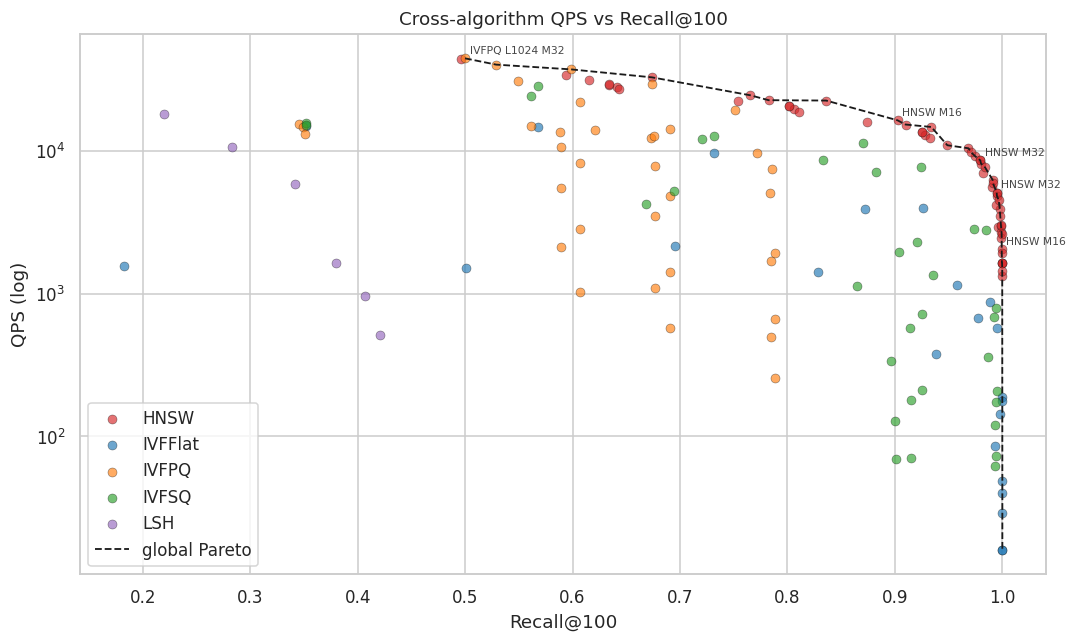

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
palette = {'IVFFlat':'#1f77b4', 'IVFPQ':'#ff7f0e', 'IVFSQ':'#2ca02c',
           'HNSW':'#d62728', 'LSH':'#9467bd'}
for fam, sub in combined.groupby('family'):
    ax.scatter(sub.recall_100, sub.qps, c=palette.get(fam, 'k'), label=fam,
               s=35, alpha=0.65, edgecolors='k', linewidth=0.3)

# global Pareto — annotate hull only (≤5 labels)
mask = utils.pareto_frontier(combined.recall_100.values, combined.qps.values)
order = np.argsort(combined.recall_100.values[mask])
ax.plot(combined.recall_100.values[mask][order], combined.qps.values[mask][order],
        'k--', lw=1.2, label='global Pareto')
df_p = combined.iloc[np.where(mask)[0]].sort_values('recall_100')
for _, r in df_p.iloc[::max(1, len(df_p) // 5)][:5].iterrows():
    lbl = f"{r.algo}"
    if pd.notna(r.get('nlist')): lbl += f" L{int(r.nlist)}"
    if pd.notna(r.get('M')): lbl += f" M{int(r.M)}"
    ax.annotate(lbl, (r.recall_100, r.qps), fontsize=7, alpha=0.85,
                xytext=(3, 3), textcoords='offset points')
ax.set_yscale('log'); ax.set_xlabel('Recall@100'); ax.set_ylabel('QPS (log)')
ax.set_title('Cross-algorithm QPS vs Recall@100')
ax.legend()
plt.tight_layout(); plt.savefig(DOCS_IMG / '05_global_pareto.png', dpi=120); plt.show()

## 2 · Best configurations summary

In [4]:
THRESHOLDS = [0.95, 0.9, 0.8, 0.5, 0.2]
OPERATIONAL_THR = 0.95

def _row_to_record(fam, scenario, thr, is_fb, b):
    cfg_parts = []
    for c in ['nlist', 'nprobe', 'M', 'efConstruction', 'efSearch', 'nbits', 'sq']:
        if c in b.index and pd.notna(b[c]):
            cfg_parts.append(f'{c}={b[c]}')
    rss_after = float(b['rss_mb']) if pd.notna(b.get('rss_mb')) else float('nan')
    rss_peak = float(b['rss_peak_mb']) if 'rss_peak_mb' in b.index and pd.notna(b.get('rss_peak_mb')) else rss_after
    rss_delta = float(b['rss_delta_mb']) if 'rss_delta_mb' in b.index and pd.notna(b.get('rss_delta_mb')) else float('nan')
    lat_p99 = float(b['latency_p99_ms']) if 'latency_p99_ms' in b.index and pd.notna(b.get('latency_p99_ms')) else float('nan')
    return dict(
        family=fam, scenario=scenario, threshold=thr, threshold_fallback=is_fb,
        recall_100=b.recall_100, qps=b.qps, size_mb=b.size_mb,
        latency_ms=float(b['latency_ms']) if pd.notna(b.get('latency_ms')) else float('nan'),
        latency_p99_ms=lat_p99,
        build_s=float(b['build_s']) if 'build_s' in b.index and pd.notna(b.get('build_s')) else float('nan'),
        rss_mb=rss_after, rss_peak_mb=rss_peak, rss_delta_mb=rss_delta,
        config=', '.join(cfg_parts),
    )

def best_operational_row(sub, thr=OPERATIONAL_THR):
    cand = sub[sub.recall_100 >= thr]
    if len(cand):
        return thr, cand.sort_values(['qps', 'recall_100'], ascending=[False, False]).iloc[0], False
    return 0.0, sub.sort_values(['recall_100', 'qps'], ascending=[False, False]).iloc[0], True

scenario_rows = []
summary_rows = []
for fam in sorted(combined['family'].unique()):
    sub = combined[combined.family == fam]
    br = sub.sort_values(['recall_100', 'qps'], ascending=[False, False]).iloc[0]
    scenario_rows.append(_row_to_record(fam, 'best_recall', 0.0, True, br))
    bf = sub.sort_values(['size_mb', 'recall_100'], ascending=[True, False]).iloc[0]
    scenario_rows.append(_row_to_record(fam, 'best_footprint', 0.0, True, bf))
    for thr in THRESHOLDS:
        cand = sub[sub.recall_100 >= thr]
        if len(cand):
            bq = cand.sort_values(['qps', 'recall_100'], ascending=[False, False]).iloc[0]
            scenario_rows.append(_row_to_record(fam, f'best_qps_at_{thr}', thr, False, bq))
    thr, b, is_fb = best_operational_row(sub)
    summary_rows.append(_row_to_record(fam, 'operational', thr, is_fb, b))

summary = pd.DataFrame(summary_rows)
scenarios = pd.DataFrame(scenario_rows)
display(summary)
display(scenarios)
summary.to_csv(RESULTS / 'best_configs.csv', index=False)
scenarios.to_csv(RESULTS / 'best_configs_scenarios.csv', index=False)
print(f'Operational pick: max QPS among recall>={OPERATIONAL_THR} (else highest recall). See best_configs_scenarios.csv for alternatives.')

,family,scenario,threshold,threshold_fallback,recall_100,qps,size_mb,latency_ms,latency_p99_ms,build_s,rss_mb,rss_peak_mb,rss_delta_mb,config
0,HNSW,operational,0.95,False,0.968478,10418.480025,3975.048578,0.095808,0.164102,112.846378,4531.808594,10795.140625,3994.800781,"M=16.0, efConstruction=200.0, efSearch=80.0"
1,IVFFlat,operational,0.95,False,0.958067,1141.885572,4038.189830,0.875610,1.082524,2566.328405,9636.605469,13234.070312,2866.843750,"nlist=16384.0, nprobe=64.0"
2,IVFPQ,operational,0.00,True,0.788076,255.652673,74.857838,3.911651,4.157535,186.414403,6969.312500,15620.136719,113.585938,"nlist=1024.0, nprobe=1024.0, M=128.0, nbits=8.0"
3,IVFSQ,operational,0.95,False,0.973561,2826.699412,988.400810,0.356594,0.519823,166.029675,7013.761719,11300.617188,175.339844,"nlist=1024.0, nprobe=16.0, sq=SQ8"
4,LSH,operational,0.00,True,0.420694,514.505931,276.140714,1.944663,2.304901,60.732132,2501.558594,7581.628906,244.250000,nbits=4096.0


,family,scenario,threshold,threshold_fallback,recall_100,qps,size_mb,latency_ms,latency_p99_ms,build_s,rss_mb,rss_peak_mb,rss_delta_mb,config
0,HNSW,best_recall,0.00,True,0.999887,1435.146635,4036.012667,0.699071,1.299212,252.119201,4599.093750,11162.671875,4034.667969,"M=32.0, efConstruction=400.0, efSearch=640.0"
1,HNSW,best_footprint,0.00,True,0.996272,2923.035990,3944.671679,0.342115,0.586673,88.633670,4443.175781,10943.308594,3946.027344,"M=8.0, efConstruction=200.0, efSearch=640.0"
2,HNSW,best_qps_at_0.95,0.95,False,0.968478,10418.480025,3975.048578,0.095808,0.164102,112.846378,4531.808594,10795.140625,3994.800781,"M=16.0, efConstruction=200.0, efSearch=80.0"
3,HNSW,best_qps_at_0.9,0.90,False,0.902436,16355.836693,3975.048578,0.061110,0.097476,112.846378,4531.808594,10795.140625,3994.800781,"M=16.0, efConstruction=200.0, efSearch=40.0"
4,HNSW,best_qps_at_0.8,0.80,False,0.835980,22492.110302,3944.671679,0.044571,0.065185,88.633670,4443.175781,10943.308594,3946.027344,"M=8.0, efConstruction=200.0, efSearch=40.0"
5,HNSW,best_qps_at_0.5,0.50,False,0.593598,33919.481074,3975.048578,0.029360,0.041699,112.846378,4531.808594,10795.140625,3994.800781,"M=16.0, efConstruction=200.0, efSearch=10.0"
6,HNSW,best_qps_at_0.2,0.20,False,0.496334,43897.197207,3944.671679,0.022799,0.029234,88.633670,4443.175781,10943.308594,3946.027344,"M=8.0, efConstruction=200.0, efSearch=10.0"
7,IVFFlat,best_recall,0.00,True,0.999996,16.131020,3918.072642,61.995265,64.086189,164.052858,9296.410156,13594.699219,4712.113281,"nlist=1024.0, nprobe=1024.0"
8,IVFFlat,best_footprint,0.00,True,0.999996,16.066254,3912.066783,62.239723,64.183328,44.696852,9098.210938,13348.328125,4769.257812,"nlist=256.0, nprobe=256.0"
9,IVFFlat,best_qps_at_0.95,0.95,False,0.958067,1141.885572,4038.189830,0.875610,1.082524,2566.328405,9636.605469,13234.070312,2866.843750,"nlist=16384.0, nprobe=64.0"


Operational pick: max QPS among recall>=0.95 (else highest recall). See best_configs_scenarios.csv for alternatives.


## 3 · Build time / index size / RSS comparison (operational best configs)

Peak RSS bars include **mmap page-cache** during `stream_add`, not index size alone — compare `size_mb` and `rss_delta_mb` for process growth.

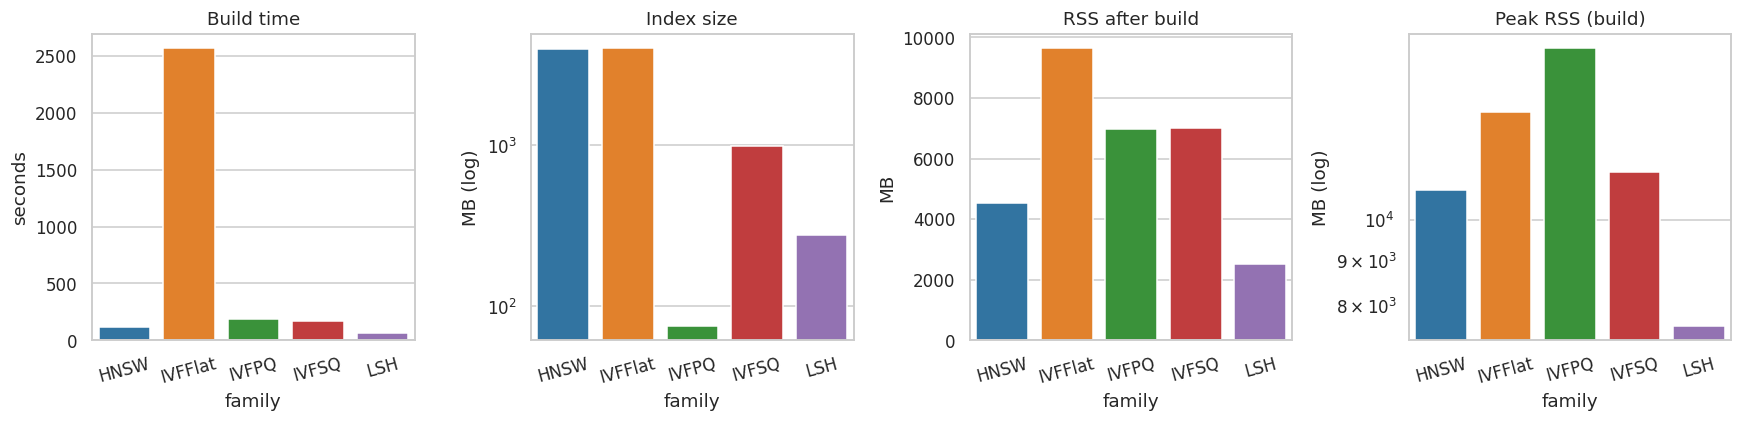

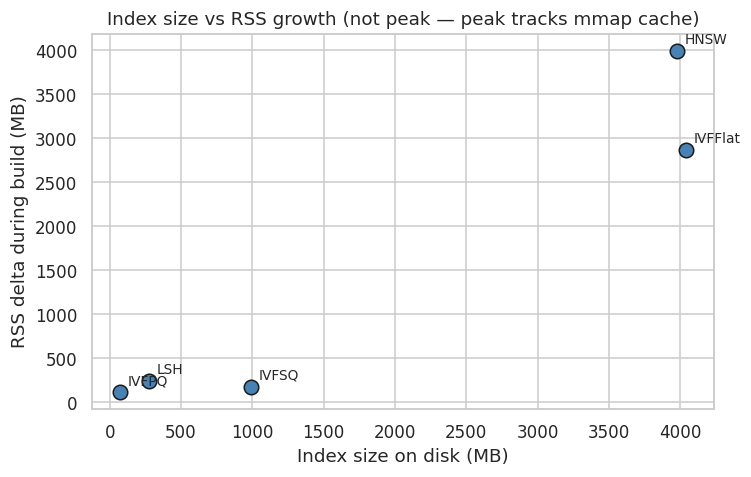

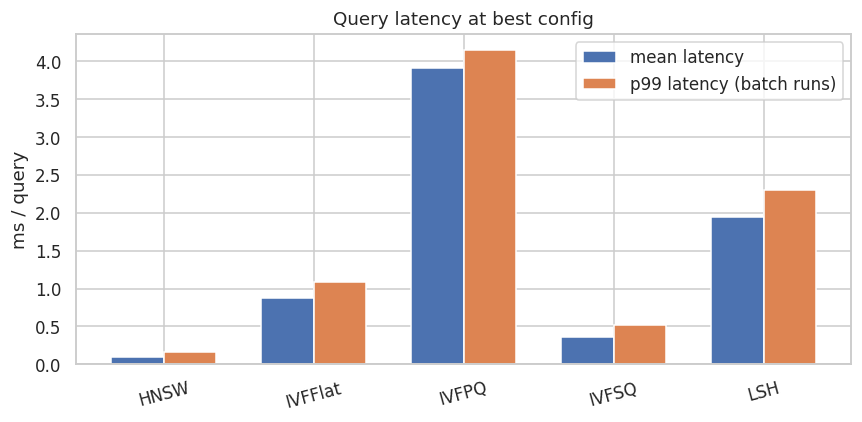

In [5]:
sum_plot = summary.copy().sort_values('family')

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
sns.barplot(data=sum_plot, x='family', y='build_s', ax=ax[0], hue='family', palette='tab10', legend=False)
ax[0].set_title('Build time'); ax[0].set_ylabel('seconds')
sns.barplot(data=sum_plot, x='family', y='size_mb', ax=ax[1], hue='family', palette='tab10', legend=False)
ax[1].set_yscale('log'); ax[1].set_title('Index size'); ax[1].set_ylabel('MB (log)')
sns.barplot(data=sum_plot, x='family', y='rss_mb', ax=ax[2], hue='family', palette='tab10', legend=False)
ax[2].set_title('RSS after build'); ax[2].set_ylabel('MB')
sns.barplot(data=sum_plot, x='family', y='rss_peak_mb', ax=ax[3], hue='family', palette='tab10', legend=False)
ax[3].set_yscale('log'); ax[3].set_title('Peak RSS (build)'); ax[3].set_ylabel('MB (log)')
for a in ax:
    a.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.savefig(DOCS_IMG / '05_best_bars.png', dpi=120); plt.show()

# Index size vs RSS delta (peak includes mmap page-cache for stream_add)
fig, ax = plt.subplots(figsize=(7, 4.5))
if 'rss_delta_mb' in sum_plot.columns:
    ax.scatter(sum_plot['size_mb'], sum_plot['rss_delta_mb'], s=90, c='steelblue', edgecolors='k')
    ax.set_ylabel('RSS delta during build (MB)')
    ax.set_title('Index size vs RSS growth (not peak — peak tracks mmap cache)')
else:
    ax.scatter(sum_plot['size_mb'], sum_plot['rss_peak_mb'], s=90, c='steelblue', edgecolors='k')
    ax.set_ylabel('Peak RSS (MB)')
    ax.set_title('Index size vs peak RSS')
for _, r in sum_plot.iterrows():
    ax.annotate(r['family'], (r['size_mb'], r.get('rss_delta_mb', r['rss_peak_mb'])), fontsize=9,
                xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('Index size on disk (MB)')
plt.tight_layout(); plt.savefig(DOCS_IMG / '05_memory_sanity.png', dpi=120); plt.show()

# Latency from best-config rows
if 'latency_p99_ms' in sum_plot.columns and sum_plot['latency_p99_ms'].notna().any():
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(sum_plot))
    w = 0.35
    ax.bar(x - w/2, sum_plot['latency_ms'], width=w, label='mean latency')
    ax.bar(x + w/2, sum_plot['latency_p99_ms'], width=w, label='p99 latency (batch runs)')
    ax.set_xticks(x); ax.set_xticklabels(sum_plot['family'], rotation=15)
    ax.set_ylabel('ms / query'); ax.set_title('Query latency at best config')
    ax.legend()
    plt.tight_layout(); plt.savefig(DOCS_IMG / '05_latency_best.png', dpi=120); plt.show()

## 4 · Scaling experiment

For each algorithm's best config, rebuild at increasing dataset sizes and measure
Recall@100, QPS, build time and RSS.  We track how each algorithm scales toward the
RAM limit.

In [6]:
LAB_LIGHT_05 = int(os.environ.get('LAB_LIGHT', '0'))
N_CAP = int(os.environ.get('LAB_N_SWEEP', '500000'))
QPS_REPEAT = int(os.environ.get('LAB_QPS_REPEAT', '2' if LAB_LIGHT_05 else '1'))
QPS_WARMUP = int(os.environ.get('LAB_QPS_WARMUP', '1' if LAB_LIGHT_05 else '0'))

if LAB_LIGHT_05:
    # One small scale point only — full scaling is hours of rebuilds.
    SCALES = [min(50_000, N_CAP, N_BASE)]
    print('LAB_LIGHT=1 — scaling section uses a single N:', SCALES)
else:
    SCALES = [100_000, 250_000, 500_000, 1_000_000]
    if int(os.environ.get('LAB_SCALING_FULL', '0')):
        SCALES.append(N_BASE)
    SCALES = sorted({s for s in SCALES if s <= N_BASE})
print(f"QPS_REPEAT={QPS_REPEAT}  QPS_WARMUP={QPS_WARMUP}  LAB_SCALING_FULL={os.environ.get('LAB_SCALING_FULL','0')}")

def ensure_gt(n: int, k: int = 100):
    cache = DATA / f'gt_n{n}_k{k}.npy'
    if cache.exists():
        return np.load(cache)
    flat = faiss.IndexFlatL2(DIM)
    utils.stream_add(flat, BASE_PATH, n)
    _, I = flat.search(queries, k)
    np.save(cache, I)
    del flat; gc.collect()
    return I

_scale_csv = RESULTS / 'scaling.csv'
if os.environ.get('SKIP_SCALING_REBUILD', '0') == '1' and _scale_csv.exists():
    df_scale = pd.read_csv(_scale_csv)
    print(f'SKIP_SCALING_REBUILD=1 — using existing {_scale_csv} ({len(df_scale)} rows)')
else:
    scale_rows = []
    _nl = 256 if LAB_LIGHT_05 else 4096
    _np = min(64, _nl)

    # One representative config per family (always include LSH when present in combined)
    configs = []
    for fam in ['IVFFlat', 'IVFPQ', 'IVFSQ', 'HNSW', 'LSH']:
        if fam not in combined['family'].values:
            continue
        if fam == 'IVFFlat':
            cfg = dict(nlist=_nl, nprobe=_np)
        elif fam == 'IVFPQ':
            cfg = dict(nlist=_nl, nprobe=_np, M=64)
        elif fam == 'IVFSQ':
            cfg = dict(nlist=_nl, nprobe=_np, sq='SQ8')
        elif fam == 'HNSW':
            cfg = dict(M=32, efC=200, efS=160)
        else:
            lsh_sub = combined[combined.family == 'LSH']
            nb = int(lsh_sub.sort_values(['recall_100', 'qps'], ascending=[False, False]).iloc[0]['nbits'])
            cfg = dict(nbits=nb)
        configs.append((fam, cfg))
    print('scaling configs (all families in combined):', configs)

    def build_search(family, cfg, n, q, k=100):
        # Match the per-notebook IVF clustering parameters so build_s / RSS
        # in scaling.csv stay comparable to the per-family CSVs.
        if family == 'IVFFlat':
            quant = faiss.IndexFlatL2(DIM)
            idx = faiss.IndexIVFFlat(quant, DIM, cfg['nlist'])
            idx.cp.min_points_per_centroid = 5
        elif family == 'IVFPQ':
            quant = faiss.IndexFlatL2(DIM)
            idx = faiss.IndexIVFPQ(quant, DIM, cfg['nlist'], cfg['M'], 8)
            idx.cp.min_points_per_centroid = 5
        elif family == 'IVFSQ':
            quant = faiss.IndexFlatL2(DIM)
            idx = faiss.IndexIVFScalarQuantizer(quant, DIM, cfg['nlist'], faiss.ScalarQuantizer.QT_8bit)
            idx.cp.min_points_per_centroid = 5
        elif family == 'HNSW':
            idx = faiss.IndexHNSWFlat(DIM, cfg['M'])
            idx.hnsw.efConstruction = cfg['efC']
        elif family == 'LSH':
            idx = faiss.IndexLSH(DIM, cfg['nbits'])
        else:
            return None

        # Use the same train slice the per-notebook sweeps use (200 000).
        TRAIN_N_SCALING = 200_000
        with utils.timed(f'{family} build', sample_rss_peak=True) as tb:
            if hasattr(idx, 'is_trained') and not idx.is_trained:
                train_x = utils.load_train_subset(BASE_PATH, min(n, TRAIN_N_SCALING))
                # Match cp.max_points_per_centroid override too.
                if family.startswith('IVF') and hasattr(idx, 'cp'):
                    idx.cp.max_points_per_centroid = max(
                        256, len(train_x) // max(1, cfg.get('nlist', 1)))
                idx.train(train_x)
                del train_x; gc.collect()
            utils.stream_add(idx, BASE_PATH, n)
        if 'nprobe' in cfg:
            idx.nprobe = cfg['nprobe']
        if family == 'HNSW':
            idx.hnsw.efSearch = cfg['efS']
        size_mb = utils.index_size_mb(idx)
        rss_mb = tb.rss_after_mb
        rss_peak_mb = tb.rss_peak_mb
        rss_delta_mb = tb.rss_delta_mb
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q2, k2: idx.search(q2, k2), q, k,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        del idx
        gc.collect()
        return tb.elapsed, size_mb, rss_mb, rss_peak_mb, rss_delta_mb, qps, lat_ms, lat_p99_ms, I

    for n in SCALES:
        print()
        print(f'=== n={n:,} ===')
        gt_loc = ensure_gt(n)
        utils.print_mem(f'before configs at n={n}')
        for fam, cfg in configs:
            try:
                t_build, size_mb, rss_mb, rss_peak_mb, rss_delta_mb, qps, lat_ms, lat_p99_ms, I = build_search(fam, cfg, n, queries)
                recalls = utils.compute_recalls(I, gt_loc, (1, 10, 100))
                scale_rows.append(dict(family=fam, n=n, config=str(cfg),
                                        build_s=t_build, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                                        rss_delta_mb=rss_delta_mb, qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100]))
                print(f'   {fam:8} n={n:>8,}  build={t_build:6.1f}s  size={size_mb:6.0f}MB  peakRSS={rss_peak_mb:6.0f}MB  '
                      f'qps={qps:7.1f}  R@100={recalls[100]:.3f}')
            except Exception as e:
                print(f'   {fam:8} n={n:>8,}  FAILED: {e}')
            gc.collect()
        gc.collect()

    df_scale = pd.DataFrame(scale_rows)
    df_scale.to_csv(_scale_csv, index=False)
display(df_scale)

QPS_REPEAT=3  QPS_WARMUP=1  LAB_SCALING_FULL=0
scaling configs (all families in combined): [('IVFFlat', {'nlist': 4096, 'nprobe': 64}), ('IVFPQ', {'nlist': 4096, 'nprobe': 64, 'M': 64}), ('IVFSQ', {'nlist': 4096, 'nprobe': 64, 'sq': 'SQ8'}), ('HNSW', {'M': 32, 'efC': 200, 'efS': 160}), ('LSH', {'nbits': 4096})]

=== n=100,000 ===
[mem before configs at n=100000]  RSS=0.55 GB  ·  free=29.44 GB  ·  used%=10


add (n=100,000, batch=50,000):   0%|                                                          | 0/2 [00:00<?, ?it/s]

add (n=100,000, batch=50,000):  50%|█████████████████████████                         | 1/2 [00:05<00:05,  5.97s/it]

add (n=100,000, batch=50,000): 100%|██████████████████████████████████████████████████| 2/2 [00:11<00:00,  6.00s/it]

   IVFFlat  n= 100,000  build= 130.4s  size=   814MB  peakRSS=  2534MB  qps= 6048.8  R@100=0.931


...

add (n=1,000,000, batch=50,000):  90%|█████████████████████████████████████████▍    | 18/20 [01:54<00:12,  6.15s/it]

add (n=1,000,000, batch=50,000):  95%|███████████████████████████████████████████▋  | 19/20 [02:00<00:06,  6.13s/it]

add (n=1,000,000, batch=50,000): 100%|██████████████████████████████████████████████| 20/20 [02:07<00:00,  6.11s/it]

   LSH      n=1,000,000  build= 127.2s  size=   520MB  peakRSS= 10264MB  qps=  270.1  R@100=0.416


,family,n,config,build_s,size_mb,rss_mb,rss_peak_mb,rss_delta_mb,qps,latency_ms,latency_p99_ms,recall_1,recall_10,recall_100
0,IVFFlat,100000,"{'nlist': 4096, 'nprobe': 64}",130.414742,814.044322,1457.929688,2534.445312,935.437500,6048.809851,0.165384,0.209194,0.99108,0.979720,0.930688
1,IVFPQ,100000,"{'nlist': 4096, 'nprobe': 64, 'M': 64}",143.825877,40.897877,1373.281250,4849.589844,263.246094,10229.356464,0.098450,0.168605,0.55664,0.618460,0.677370
2,IVFSQ,100000,"{'nlist': 4096, 'nprobe': 64, 'sq': 'SQ8'}",142.026348,228.122490,1108.371094,2647.683594,39.074219,8847.168452,0.113757,0.168608,0.98408,0.974868,0.929815
3,HNSW,100000,"{'M': 32, 'efC': 200, 'efS': 160}",11.521709,807.209810,1863.398438,3035.714844,781.257812,9557.111335,0.104607,0.169545,0.99432,0.993964,0.982776
4,LSH,100000,{'nbits': 4096},12.191753,80.828214,1170.421875,3123.992188,104.835938,1879.655564,0.530628,0.724759,0.39524,0.498740,0.552041
5,IVFFlat,250000,"{'nlist': 4096, 'nprobe': 64}",267.732532,1987.063731,3184.300781,5367.769531,2168.000000,1950.876356,0.512473,0.695538,0.99600,0.989560,0.966833
6,IVFPQ,250000,"{'nlist': 4096, 'nprobe': 64, 'M': 64}",284.096736,51.197559,1996.304688,6645.066406,40.046875,9275.232711,0.107644,0.137657,0.51368,0.600160,0.654913
7,IVFSQ,250000,"{'nlist': 4096, 'nprobe': 64, 'sq': 'SQ8'}",279.910896,522.235649,2005.089844,5049.800781,80.304688,5112.382665,0.195578,0.263681,0.98604,0.982592,0.964681
8,HNSW,250000,"{'M': 32, 'efC': 200, 'efS': 160}",47.405155,2018.015047,3450.347656,6844.367188,2018.007812,5982.420781,0.167084,0.305237,0.99776,0.997716,0.990055
9,LSH,250000,{'nbits': 4096},30.460541,154.070401,1500.703125,4626.710938,122.984375,935.187431,1.069382,1.278890,0.33704,0.438332,0.506667


### Plot — Recall@100 / QPS / Build time / RSS vs N

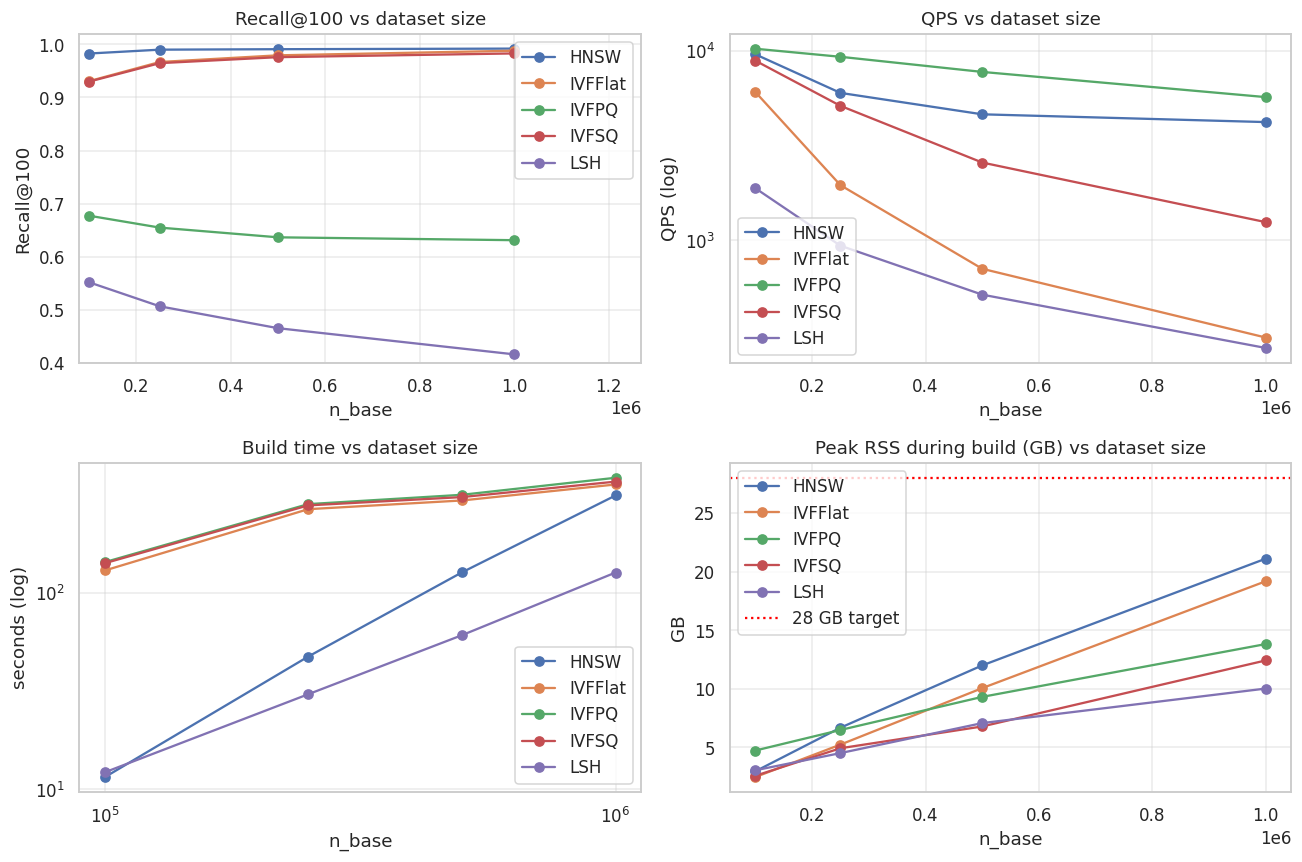

In [7]:
import os as _os
if len(df_scale) == 0:
    print('No scaling rows — skipping plot.')
elif _os.environ.get('LAB_LIGHT') == '1' and df_scale['n'].nunique() < 2:
    print('LAB_LIGHT: single scaling point — bar-style snapshot instead of curves.')
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    snap = df_scale.sort_values('family')
    rss_c = 'rss_peak_mb' if 'rss_peak_mb' in snap.columns else 'rss_mb'
    sns.barplot(data=snap, x='family', y='recall_100', ax=axes[0], palette='tab10')
    axes[0].set_title(f"Recall@100  (N={int(snap['n'].iloc[0]):,})")
    sns.barplot(data=snap, x='family', y='qps', ax=axes[1], palette='tab10')
    axes[1].set_yscale('log'); axes[1].set_title('QPS')
    sns.barplot(data=snap, x='family', y='build_s', ax=axes[2], palette='tab10')
    axes[2].set_title('Build time (s)')
    sns.barplot(data=snap, x='family', y=rss_c, ax=axes[3], palette='tab10')
    axes[3].set_yscale('log'); axes[3].set_title('Peak RSS (MB)')
    for a in axes:
        a.tick_params(axis='x', rotation=20)
    plt.tight_layout(); plt.savefig(DOCS_IMG / '05_scaling.png', dpi=120); plt.show()
else:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    rss_col = 'rss_peak_mb' if 'rss_peak_mb' in df_scale.columns else 'rss_mb'
    for fam, sub in df_scale.groupby('family'):
        sub = sub.sort_values('n')
        axes[0,0].plot(sub.n, sub.recall_100, marker='o', label=fam)
        axes[0,1].plot(sub.n, sub.qps, marker='o', label=fam)
        axes[1,0].plot(sub.n, sub.build_s, marker='o', label=fam)
        axes[1,1].plot(sub.n, sub[rss_col] / 1024, marker='o', label=fam)  # MB → GB
    axes[0,0].set_title('Recall@100 vs dataset size')
    axes[0,0].set_xlabel('n_base'); axes[0,0].set_ylabel('Recall@100'); axes[0,0].set_ylim(0.4, 1.02)
    axes[0,0].set_xlim(left=min(df_scale['n'].min(), 80_000), right=max(df_scale['n'].max(), N_BASE * 0.99))
    axes[0,1].set_title('QPS vs dataset size')
    axes[0,1].set_xlabel('n_base'); axes[0,1].set_ylabel('QPS (log)'); axes[0,1].set_yscale('log')
    axes[1,0].set_title('Build time vs dataset size')
    axes[1,0].set_xlabel('n_base'); axes[1,0].set_ylabel('seconds (log)')
    axes[1,0].set_xscale('log'); axes[1,0].set_yscale('log')
    axes[1,1].set_title('Peak RSS during build (GB) vs dataset size')
    axes[1,1].set_xlabel('n_base'); axes[1,1].set_ylabel('GB')
    axes[1,1].axhline(28, color='red', ls=':', label='28 GB target')
    for a in axes.flat:
        a.legend(); a.grid(True, alpha=0.4)
    plt.tight_layout(); plt.savefig(DOCS_IMG / '05_scaling.png', dpi=120); plt.show()

## 5 · Anomaly analysis

Below we look for surprises in the data — cases where empirical measurements contradict
naive expectations.  For each, we either explain the cause or flag it.

=== ANOMALY CHECKLIST ===

[A] IVFFlat nlist=  256  recall monotone in nprobe: True
[A] IVFFlat nlist= 1024  recall monotone in nprobe: True
[A] IVFFlat nlist= 4096  recall monotone in nprobe: True
[A] IVFFlat nlist=16384  recall monotone in nprobe: True

[B] HNSW max Recall@100 per M:
 M  recall_100
 8    0.996272
16    0.999367
32    0.999887
48    0.999580

[C] LSH best Recall@100 = 0.421 (expect low at dim=2048)

[D] IVF+PQ build_s per (nlist, M) — first row each:
   nlist= 1024 M= 32  build_s= 195.3s
   nlist= 1024 M= 64  build_s= 178.9s
   nlist= 1024 M=128  build_s= 186.4s
   nlist= 4096 M= 32  build_s= 678.1s
   nlist= 4096 M= 64  build_s= 664.4s
   nlist= 4096 M=128  build_s= 671.0s

[E] rss_mb == rss_peak_mb for all IVF rows: False (should be False after fix)

[G] best_configs covers all families ✓
[H] IVFFlat nprobe>nlist rows: 0

Flags:
  [B] HNSW at efSearch=10: higher efC lowers max R@100 (looser graph effect)
  [B] HNSW at efSearch=20: higher efC lowers max R@100 (looser

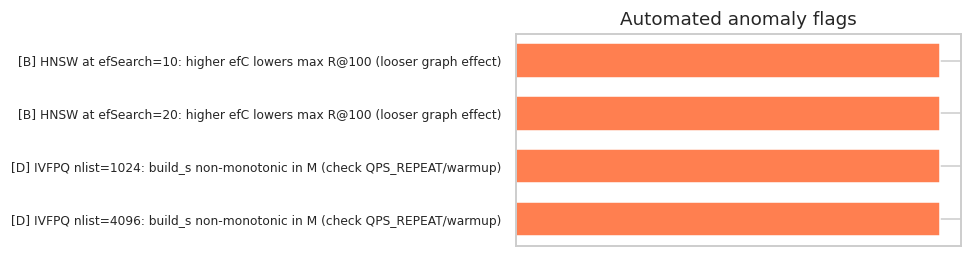

In [8]:
print('=== ANOMALY CHECKLIST ===')
print()

anomaly_flags = []
ivf = frames['IVF_all']
hnsw = frames['HNSW_all']
lsh = frames['LSH']

# A) IVFFlat recall monotone in nprobe
if ivf is not None:
    flat_ivf = ivf[ivf.algo == 'IVFFlat'].sort_values(['nlist', 'nprobe'])
    for nl, sub in flat_ivf.groupby('nlist'):
        r = sub.recall_100.values
        if np.any(np.diff(r) < -0.01):
            anomaly_flags.append(f'[A] IVFFlat nlist={nl}: recall drops with higher nprobe')
        print(f'[A] IVFFlat nlist={nl:5}  recall monotone in nprobe: {not np.any(np.diff(r) < -0.01)}')

# B) HNSW saturation + efC non-monotonicity at low efSearch
if hnsw is not None:
    sat = hnsw.groupby('M').recall_100.max().reset_index()
    print()
    print('[B] HNSW max Recall@100 per M:')
    print(sat.to_string(index=False))
    for efs in sorted(hnsw.efSearch.unique())[:3]:
        sub = hnsw[hnsw.efSearch == efs].groupby('efConstruction').recall_100.max()
        if len(sub) >= 2 and sub.iloc[-1] < sub.iloc[0] - 0.05:
            anomaly_flags.append(
                f'[B] HNSW at efSearch={efs}: higher efC lowers max R@100 (looser graph effect)')

# C) LSH recall ceiling
if lsh is not None:
    r_max = lsh.recall_100.max()
    print()
    print(f'[C] LSH best Recall@100 = {r_max:.3f} (expect low at dim={DIM})')

# D) IVF+PQ build time vs M (non-monotonic → timing noise if QPS_REPEAT=1)
if ivf is not None and (ivf.algo == 'IVFPQ').any():
    pq = ivf[ivf.algo == 'IVFPQ']
    print()
    print('[D] IVF+PQ build_s per (nlist, M) — first row each:')
    for (nl, M), sub in pq.groupby(['nlist', 'M']):
        b = sub.drop_duplicates('M')['build_s'].iloc[0]
        print(f'   nlist={int(nl):5} M={int(M):3}  build_s={b:6.1f}s')
    for nl, sub in pq.groupby('nlist'):
        bt = sub.groupby('M').build_s.first()
        if len(bt) >= 2 and (bt.diff().dropna() < -5).any():
            anomaly_flags.append(f'[D] IVFPQ nlist={nl}: build_s non-monotonic in M (check QPS_REPEAT/warmup)')

# E) rss_mb must differ from rss_peak_mb when peak tracks mmap
if ivf is not None and 'rss_delta_mb' in ivf.columns:
    same = (ivf['rss_mb'] == ivf['rss_peak_mb']).all() if 'rss_peak_mb' in ivf.columns else False
    print()
    print(f'[E] rss_mb == rss_peak_mb for all IVF rows: {same} (should be False after fix)')
    if same:
        anomaly_flags.append('[E] rss_mb still aliased to peak — RSS columns degenerate')

# F) First IVFFlat config QPS cold-start (lowest nlist, nprobe=1)
if ivf is not None:
    flat_ivf = ivf[ivf.algo == 'IVFFlat']
    cold = flat_ivf[(flat_ivf.nlist == flat_ivf.nlist.min()) & (flat_ivf.nprobe == 1)]
    hot = flat_ivf[(flat_ivf.nlist == flat_ivf.nlist.max()) & (flat_ivf.nprobe == 1)]
    if len(cold) and len(hot) and cold.qps.iloc[0] < hot.qps.iloc[0] * 0.15:
        anomaly_flags.append('[F] IVFFlat nprobe=1 QPS cold-start on smallest nlist (use QPS_WARMUP>=1)')

# G) best_configs coverage
miss = set(combined['family'].unique()) - set(summary['family'].values)
print()
if miss:
    anomaly_flags.append(f'[G] families missing from best_configs: {sorted(miss)}')
else:
    print('[G] best_configs covers all families ✓')

# H) IVFFlat invalid nprobe
if ivf is not None:
    bad = ivf[(ivf.algo == 'IVFFlat') & (ivf.nprobe > ivf.nlist)]
    print(f'[H] IVFFlat nprobe>nlist rows: {len(bad)}')

if anomaly_flags:
    print()
    print('Flags:')
    for msg in anomaly_flags:
        print(' ', msg)
    fig, ax = plt.subplots(figsize=(9, max(2.5, 0.38 * len(anomaly_flags))))
    y = np.arange(len(anomaly_flags))
    ax.barh(y, np.ones(len(anomaly_flags)), color='coral', height=0.65)
    ax.set_yticks(y)
    ax.set_yticklabels(anomaly_flags, fontsize=8)
    ax.set_title('Automated anomaly flags')
    ax.set_xticks([])
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(DOCS_IMG / '05_anomaly_flags.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print()
    print('No automated anomaly flags.')

## 6 · Final pick (one row per family from §2)

Quadrant winners use the **same** `best_configs` row for recall, QPS, and size — avoids
mixing metrics from different sweep points.

In [9]:
pick = summary.set_index('family')
display(pick[['recall_100', 'qps', 'size_mb', 'build_s', 'latency_ms', 'latency_p99_ms', 'config']])

print()
print('>>> Quadrant winners (from best_configs picks):')
print(f"    Highest recall@100: {pick['recall_100'].idxmax()}  ({pick['recall_100'].max():.3f})")
print(f"    Highest QPS at pick: {pick['qps'].idxmax()}  ({pick['qps'].max():.0f})")
print(f"    Smallest index at pick: {pick['size_mb'].idxmin()}  ({pick['size_mb'].min():.1f} MB)")

,recall_100,qps,size_mb,build_s,latency_ms,latency_p99_ms,config
family,,,,,,,
HNSW,0.968478,10418.480025,3975.048578,112.846378,0.095808,0.164102,"M=16.0, efConstruction=200.0, efSearch=80.0"
IVFFlat,0.958067,1141.885572,4038.189830,2566.328405,0.875610,1.082524,"nlist=16384.0, nprobe=64.0"
IVFPQ,0.788076,255.652673,74.857838,186.414403,3.911651,4.157535,"nlist=1024.0, nprobe=1024.0, M=128.0, nbits=8.0"
IVFSQ,0.973561,2826.699412,988.400810,166.029675,0.356594,0.519823,"nlist=1024.0, nprobe=16.0, sq=SQ8"
LSH,0.420694,514.505931,276.140714,60.732132,1.944663,2.304901,nbits=4096.0



>>> Quadrant winners (from best_configs picks):
    Highest recall@100: IVFSQ  (0.974)
    Highest QPS at pick: HNSW  (10418)
    Smallest index at pick: IVFPQ  (74.9 MB)


## 7 · Flame graph (optional)

Run after benchmarks to profile HNSW build vs IVFFlat (see `scripts/record_flame.sh`).

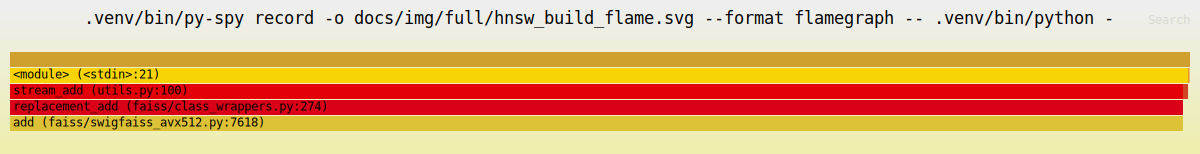

Embedded: docs/img/full/hnsw_build_flame.svg


In [10]:
_flame = DOCS_IMG / 'hnsw_build_flame.svg'
if _flame.exists():
    from IPython.display import SVG
    display(SVG(_flame.read_text()))
    print('Embedded:', _flame)
else:
    print('No flame graph yet. Generate with:')
    print('  LAB_N_SWEEP=1000000 ./scripts/record_flame.sh')
    print('(writes docs/img/full/hnsw_build_flame.svg — requires py-spy in .venv)')

## Conclusion

Headline findings (see rendered cells for numbers from this run):

* **HNSW** — best recall–QPS trade-off at high `efSearch`; build/RSS grow with `N`.
* **IVF+PQ** — smallest on-disk index; recall ceiling ≈ 0.77 even at M=128 at 2048 D.
* **IVFSQ-8** — compressed (~4× vs IVFFlat raw) and keeps R@100 ≥ 0.98; QPS bottleneck is decode-in-distance.
* **IVFFlat** — simple baseline; build time grows ~linearly with `nlist` (see log-scale bar).
* **LSH** — fast but low recall at 2048 D; even nbits=4096 only reaches R@100 ≈ 0.39.

**Methodology notes:** `rss_peak_mb` includes mmap page-cache during `stream_add`, not
index size alone. Use `rss_mb` (after build) and `rss_delta_mb` for process growth.
`latency_p99_ms` is computed across `QPS_REPEAT` batch retimings, not across individual
queries — it equals the mean when `QPS_REPEAT=1` (the full-mode default).
Scaling default stops at 1M vectors; set `LAB_SCALING_FULL=1` to measure the full
1.28M base against the 28 GB target.

### Polished report
After this notebook runs, generate the consolidated review with cleaner Pareto/budget
charts and a quantitative anomaly table:

```bash
python3 scripts/analyze_and_report.py --run full
```

It writes `docs/REPORT_full.md` plus `report_*.png`-style charts under
`docs/img/full/` without touching the per-notebook outputs.